In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

radius_values = np.concatenate([
    np.full(17, 0.0113226119),
    np.full(17, 0.0001132261),
    np.full(17, 0.0000011323)
])# m, radii needed to achieve Oh values

velocity_values = np.array([
    1.029478574, 1.455902561, 1.783109195, 2.058957148, 2.301984072, 3.255497096,
    4.603968145, 5.638686374, 6.510994191, 7.279512806, 10.29478574,
    14.55902561, 17.83109195, 20.58957148, 23.01984072, 32.55497096,
    46.03968145, 
    10.29478574, 14.55902561, 17.83109195, 20.58957148, 23.01984072,
    32.55497096, 46.03968145, 56.38686374, 65.10994191, 72.79512806,
    102.9478574, 145.5902561, 178.3109195, 205.8957148, 230.1984072,
    325.5497096, 460.3968145, 
    102.9478574, 145.5902561, 178.3109195, 205.8957148,
    230.1984072, 325.5497096, 460.3968145, 563.8686374, 651.0994191,
    727.9512806, 1029.478574, 1455.902561, 1783.109195, 2058.957148,
    2301.984072, 3255.497096, 4603.968145
])# m/s, velocity values

O'ROUKE MODEL

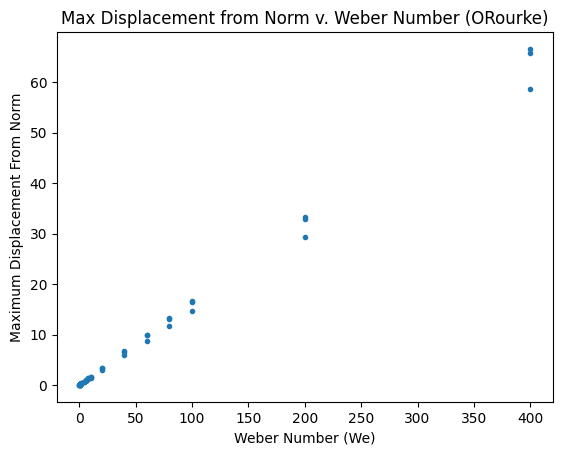

Regime Classifications: ['5' '1' '1' '2' '2' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' '5'
 '1' '1' '2' '2' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' '5' '1'
 '1' '2' '2' '>' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b']


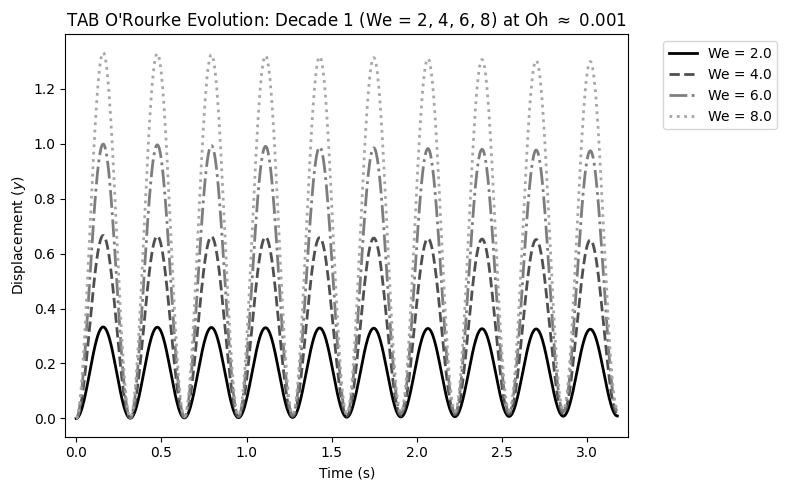

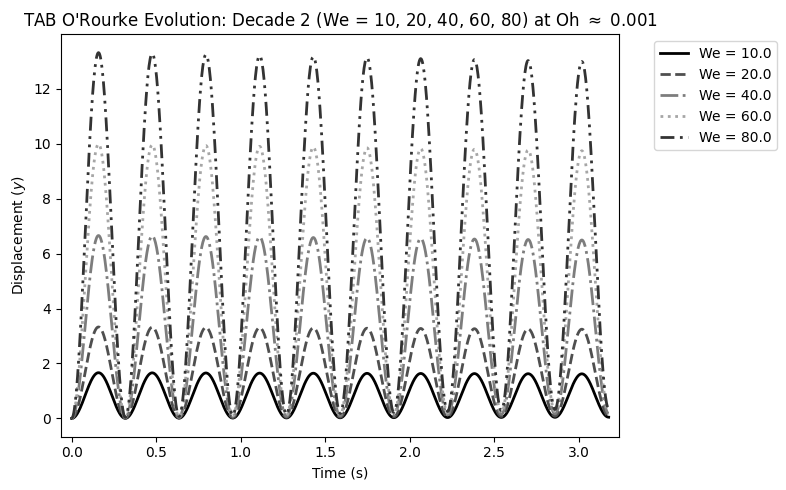

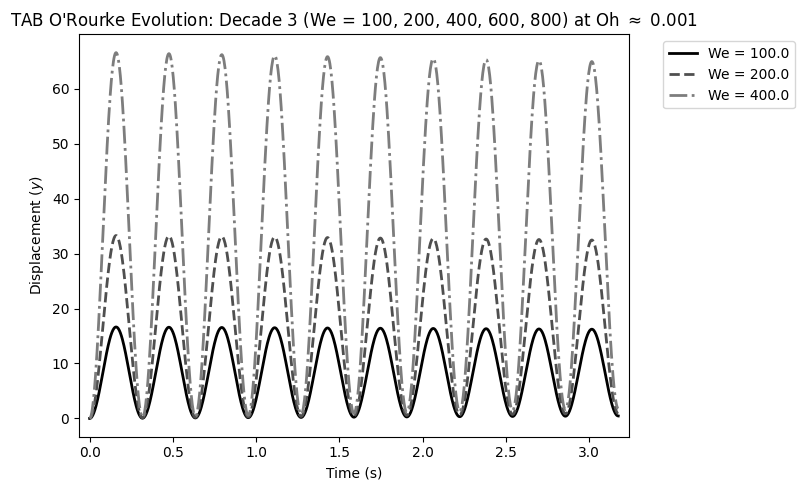

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- INITIALIZATION AND STORAGE ---
max_y_val_or = np.zeros(len(radius_values))  # array for max normalized displacement from sphere
We_or = np.zeros(len(radius_values))         # array for all the Weber numbers
regimes_Or = np.empty(len(radius_values), dtype=str)

# Storage dictionaries to hold time-series data for the decade plots
sim_results = []

for k in range(len(radius_values)):

    # All constants and initial conditions are defined here
    y_0 = 0      # initial displacement (starts as a perfect sphere)
    y_dot_0 = 0  # initial displacement velocity

    Cf = 1/3     # force constant
    Ck = 8       # linear constant
    Cd = 5       # damping constant
    Cb = 1/2     # breakup constant

    # These values may be changed:
    rho_g = 1.18  # kg/m^3, density of gaseous ethylene
    rho_l = 997   # kg/m^3, density of liquid
    r = radius_values[k]  # m, radius of droplet
    sigma = 0.0708  # kg/s^2, surface tension
    u = velocity_values[k]  # m/s, velocity

    mu_l = 0.000894  # Pa*s, the dynamic viscosity of Jet A
    t_bu = 8*np.sqrt(rho_l*r/(rho_g*u))  # breakup time of particle

    Oh = mu_l/np.sqrt(rho_l*r*sigma)  # Ohnesorge number
    We = rho_g*(u**2)*r/sigma         # Weber number
    We_or[k] = We

    omega = np.sqrt(Ck*sigma/(rho_l*r**3))  # oscillation frequency

    duration = 10*(2*np.pi/omega)  # seconds, the time we want to watch this particle
    len_t = 1000  # length of time vector

    dt = np.linspace(0, duration, len_t)  # s, time vector
    timestep = dt[1]-dt[0]  # timestep, in seconds

    t_d = (2/Cd)*(rho_l*r**2/mu_l)

    # define size of array beforehand
    y_vals = np.zeros(len_t)  # array for normalized displacements over time
    y_dot_vals = np.zeros(len_t)  # array for normalized change in displacement over time

    y_vals[0] = y_0
    y_dot_vals[0] = y_dot_0
    volume = (4/3)*np.pi*r**3  # constant

    breakup_time = 0  # Breakup time
    breakup_iteration = len_t - 1

    for i in range(len_t-1):

        # Defining some terms which show up frequently
        s = np.sin(omega*timestep)
        c = np.cos(omega*timestep)
        ex = np.exp(-timestep/t_d)
        y_We12 = y_vals[i] - We/12

        y_vals[i+1] = (We/12) + ex*((y_We12)*c + (1/omega)*(y_dot_vals[i] + (y_We12/t_d))*s)
        y_dot_vals[i+1] = (((We/12) - y_vals[i+1])/t_d) + omega*ex*((1/omega)*(y_dot_vals[i] + (y_We12/t_d))*c - (y_We12)*s)

        if (y_vals[i+1] + (We/12) > 1) and (dt[i] > t_bu):

            breakup_time = np.pi*np.sqrt((rho_l*r**3)/80)
            breakup_iteration = i
            num_drops = 13  # 13 new drops

            r_new = ((volume/num_drops)*(3/4)*(1/np.pi))**(1/3)
            Cv = 1
            spray_angle = 2*np.arctan(Cv*(np.sqrt(3)/3))*np.sqrt(rho_g/rho_l)
            vel_new = abs(Cv*Cb*r*y_dot_vals[i])

            b = np.sqrt((r**3)/(r - (y_vals[i])*r))

            new_ypos = np.zeros(num_drops)
            new_zpos = np.zeros(num_drops)
            new_xvel = np.zeros(num_drops)
            new_yvel = np.zeros(num_drops)
            new_zvel = np.zeros(num_drops)

            for j in range(num_drops):

                drop_angle = 2*np.pi*j/num_drops

                new_ypos[j] = b*np.sin(drop_angle)
                new_zpos[j] = b*np.cos(drop_angle)

                new_xvel[j] = vel_new*np.cos(spray_angle)
                new_yvel[j] = vel_new*np.sin(spray_angle)*np.sin(drop_angle)
                new_zvel[j] = vel_new*np.sin(spray_angle)*np.cos(drop_angle)

            break

    # Save data for post-processed multi-line decade plots
    # If breakup occurred, truncate the plot arrays at the breakup point to keep plots clean
    sim_results.append({
        'We': We,
        'Oh': Oh,
        't': dt[:breakup_iteration+1],
        'y': y_vals[:breakup_iteration+1]
    })
    
    peak_indices, _ = find_peaks(y_vals)
    trough_indices, _ = find_peaks(-y_vals) # Detect local minima
    peak_values = y_vals[peak_indices]

    if len(peak_indices) > 0 and len(trough_indices) > 0:
            # The amplitude of the first full oscillation cycle
            oscillation_amplitude = y_vals[peak_indices[0]] - y_vals[trough_indices[0]]
    else:
        oscillation_amplitude = 0.0

    if np.max(y_vals) <= 0.05:
        regimes_Or[k] = '5'
    elif np.max(y_vals) <= 0.1:
        regimes_Or[k] = '10'
    elif np.max(y_vals) <= 0.2:
        regimes_Or[k] = '20'
    elif np.max(y_vals)+(We/12) <= 1 and oscillation_amplitude < 0.25:
        regimes_Or[k] = '>20'
    elif np.max(y_vals)+(We/12) <= 1:
        regimes_Or[k] = 'osc'
    else:
        regimes_Or[k] = 'brk'

    # --- 1. INDIVIDUAL PLOTS WITH DYNAMIC AUTO-SCALING ---
    # plt.figure()
    # plt.plot(dt, y_vals, label='$y(t)$')
    # plt.title(f'Oscillation Values over Time, ORourke. We={We:.2f}, Oh={Oh:.3f}')
    # plt.xlabel('Time (s)')
    # plt.ylabel('Displacement from Equator')
    
    # # Enable tight auto-scaling with a small percentage margin to eliminate excess whitespace
    # plt.autoscale(enable=True, axis='both', tight=None)
    # plt.margins(x=0.02, y=0.05) 
    # plt.show()

    max_y_val_or[k] = np.max(y_vals)

# --- BASELINE DIAGNOSTIC PLOT ---
plt.figure()
plt.plot(We_or, max_y_val_or, '.')
plt.title('Max Displacement from Norm v. Weber Number (ORourke)')
plt.xlabel('Weber Number (We)')
plt.ylabel('Maximum Displacement From Norm')
plt.margins(x=0.05, y=0.05)
plt.show()

print("Regime Classifications:", regimes_Or)


# --- 2. MULTI-LINE DECADE GROUPED PLOTS BY TARGET OH (BLACK & WHITE FRIENDLY) ---
# Define the target decades
decades = {
    "Decade 1 (We = 2, 4, 6, 8)": [2, 4, 6, 8],
    "Decade 2 (We = 10, 20, 40, 60, 80)": [10, 20, 40, 60, 80],
    "Decade 3 (We = 100, 200, 400, 600, 800)": [100, 200, 400, 600, 800]
}

# Define your target Ohnesorge number for grouping (e.g., Oh = 0.001)
target_Oh = 0.001
oh_tolerance = 0.0005  # Tolerance window to group closely matched Oh numbers

# High-contrast, black-and-white friendly styles for printing
# Includes: Solid, Dashed, Dash-Dot, Dotted, and a custom Long Dash-Dot-Dot pattern
linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]
grayscale_colors = ['#000000', '#4f4f4f', '#7d7d7d', '#a6a6a6', '#333333']

for decade_name, target_We_list in decades.items():
    plt.figure(figsize=(8, 5))
    lines_plotted = 0
    
    for res in sim_results:
        # Check if the run belongs to our target Oh cluster
        if np.isclose(res['Oh'], target_Oh, atol=oh_tolerance):
            # Check if current run's We is close to any of our target values in this specific decade
            if any(np.isclose(res['We'], target_val, rtol=0.05) for target_val in target_We_list):
                
                # Dynamically assign a unique style and shade based on the line index
                style = linestyles[lines_plotted % len(linestyles)]
                color = grayscale_colors[lines_plotted % len(grayscale_colors)]
                
                plt.plot(
                    res['t'], 
                    res['y'], 
                    linestyle=style, 
                    color=color, 
                    linewidth=2.0,  # Slightly thicker lines make patterns much easier to distinguish in print
                    label=f'We = {res["We"]:.1f}'
                )
                lines_plotted += 1
                
    if lines_plotted > 0:
        plt.title(f'TAB O\'Rourke Evolution: {decade_name} at Oh $\\approx$ {target_Oh}')
        plt.xlabel('Time (s)')
        plt.ylabel('Displacement ($y$)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.margins(x=0.02, y=0.05)
        plt.tight_layout()
        plt.show()
    else:
        plt.close() # Close empty plots if no matching runs are found for a decade

TANNER MODEL

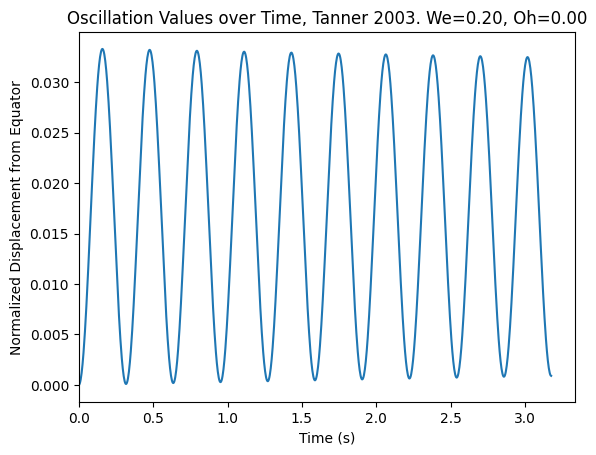

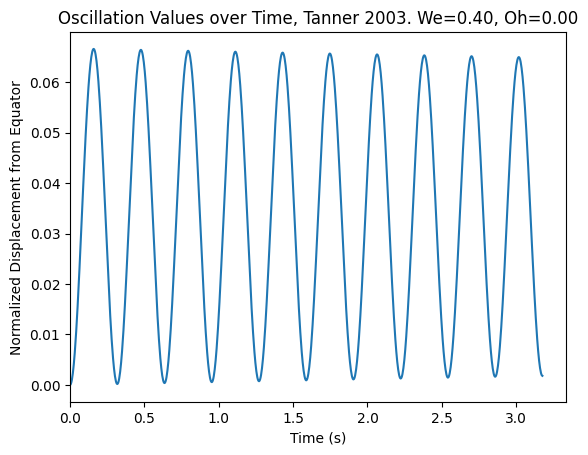

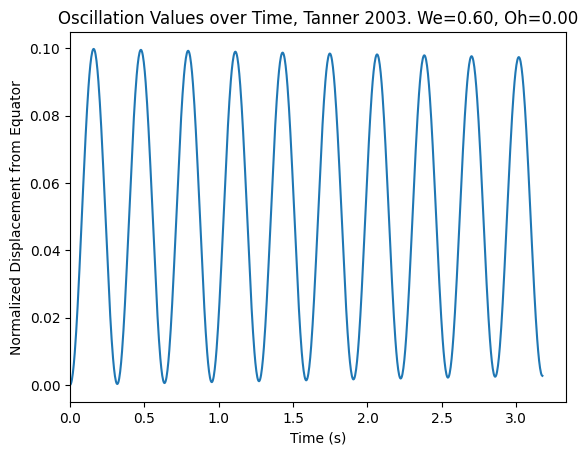

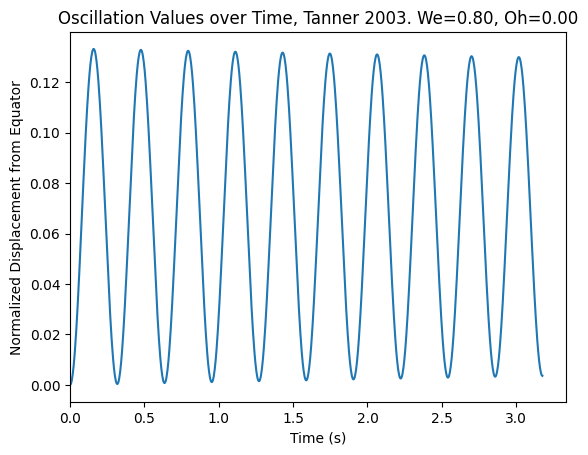

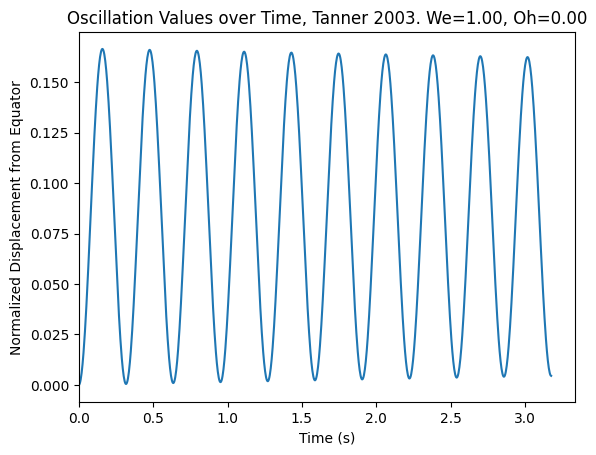

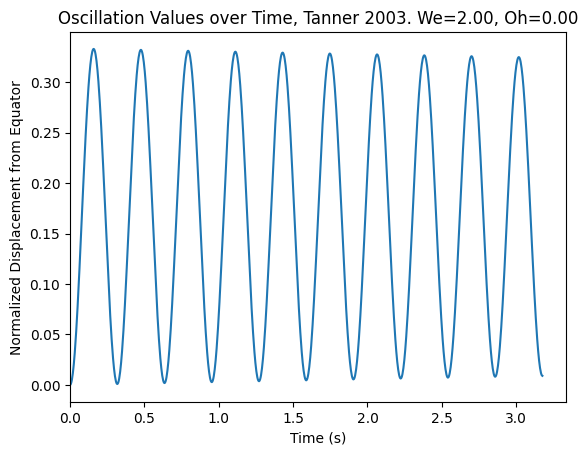

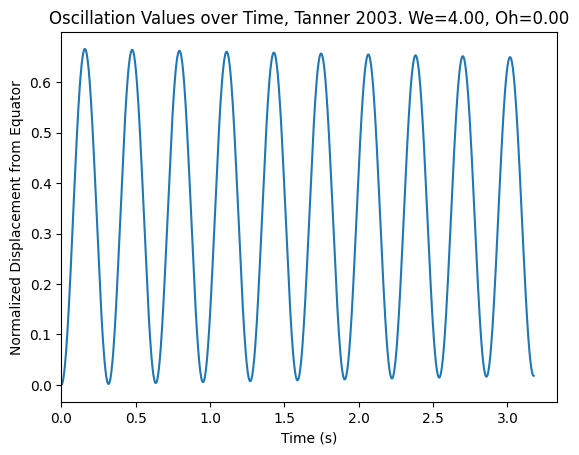

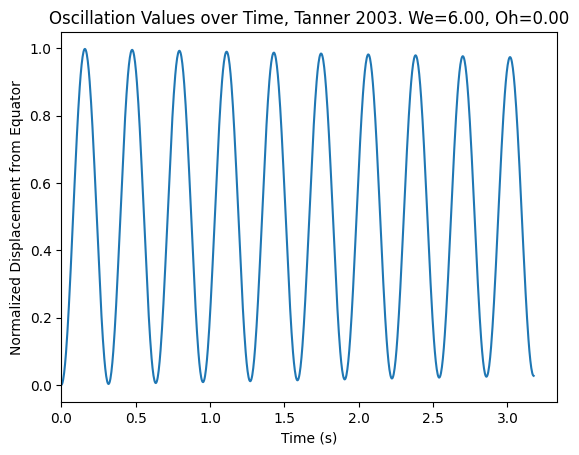

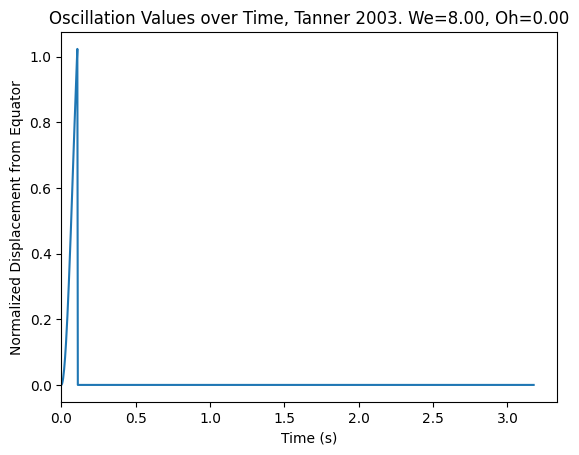

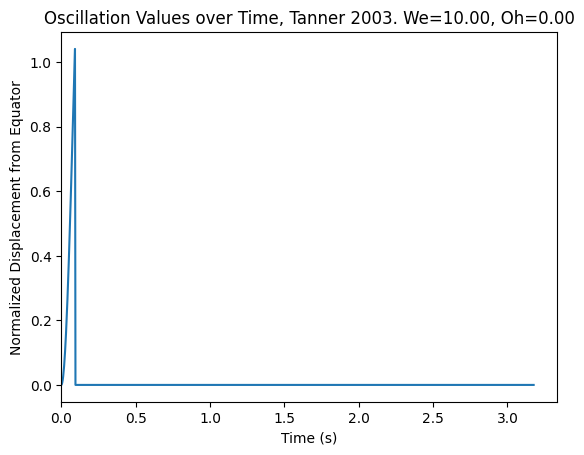

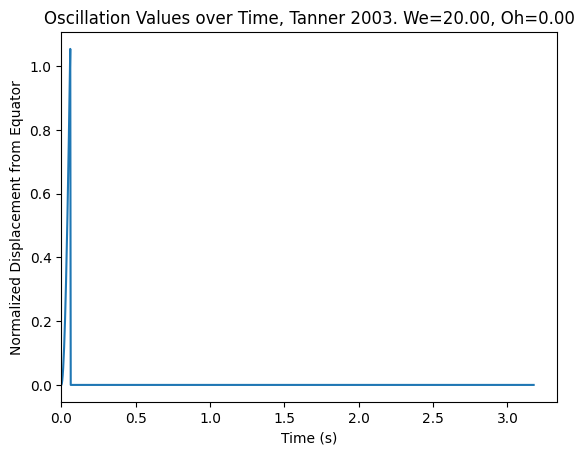

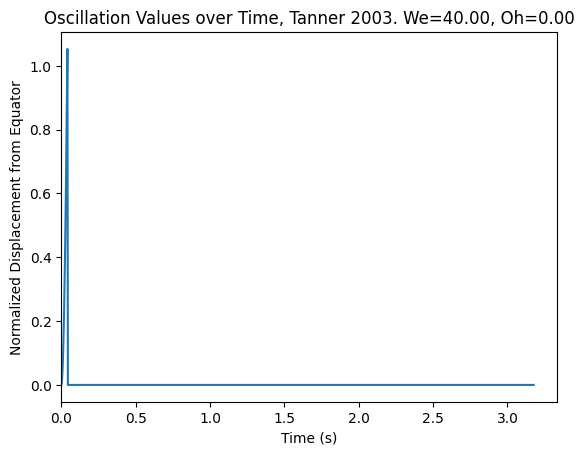

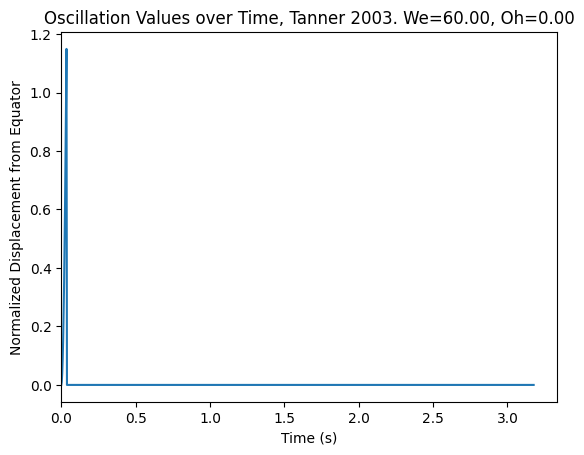

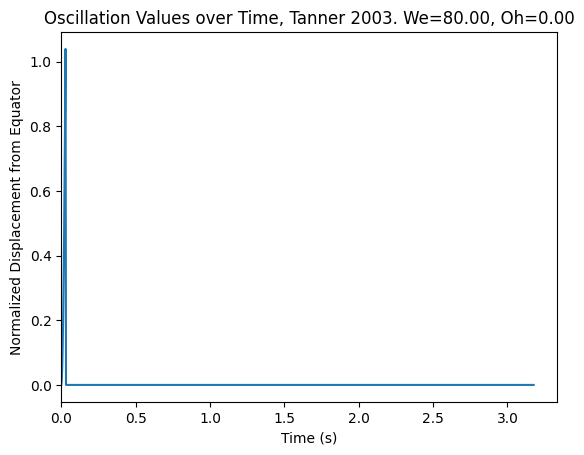

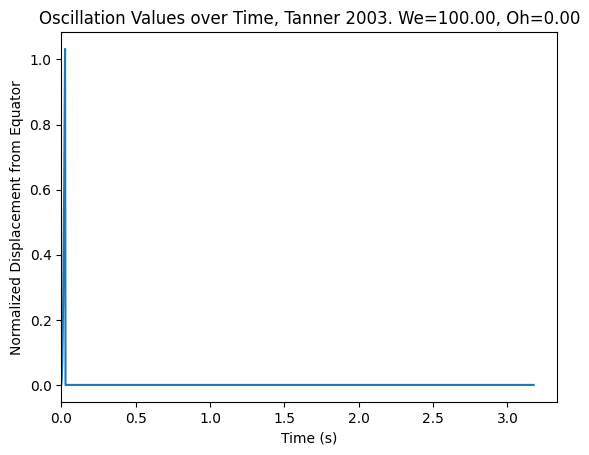

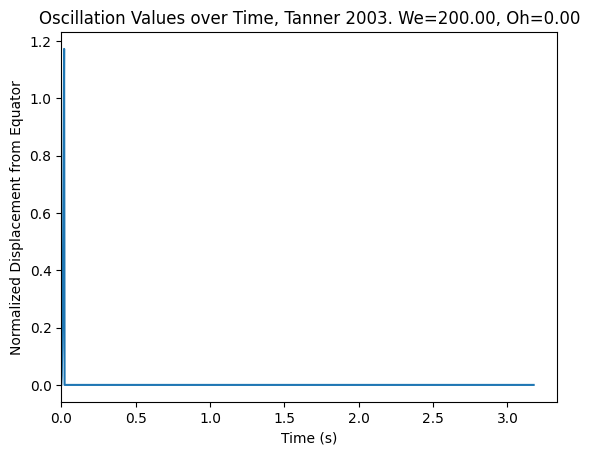

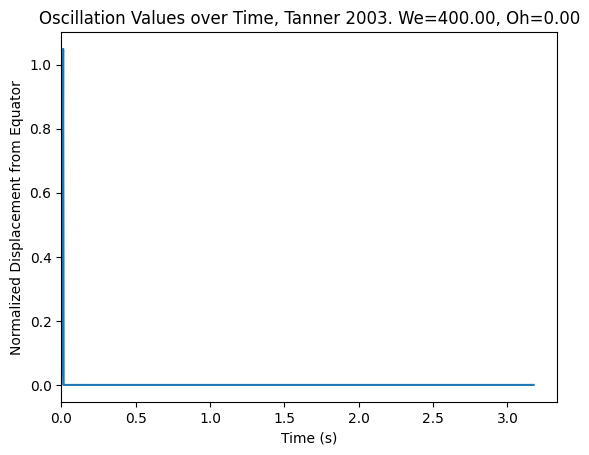

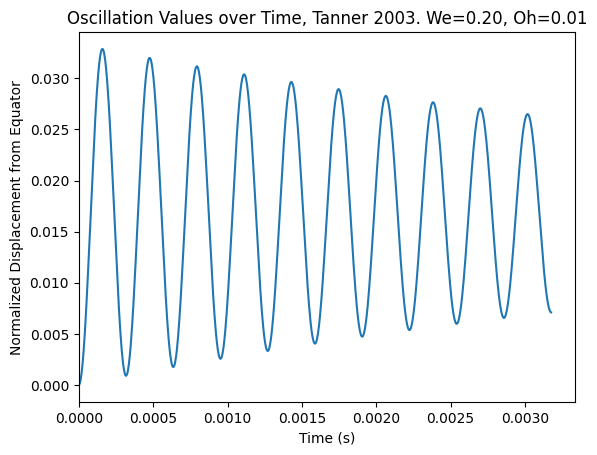

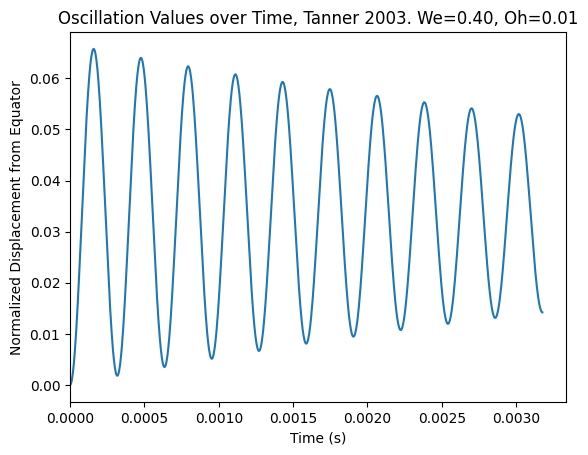

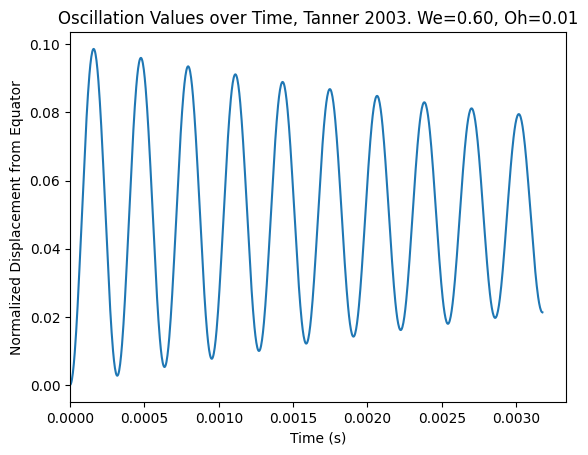

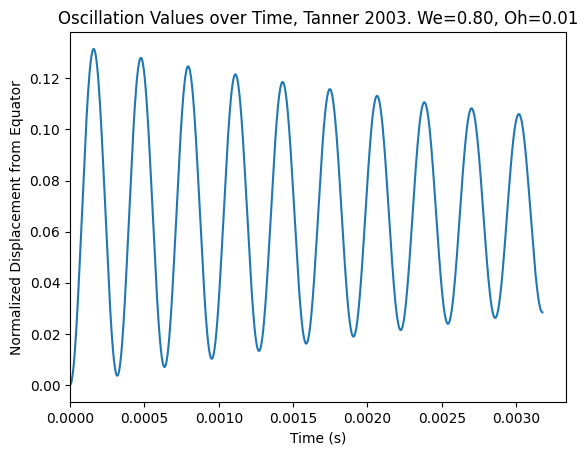

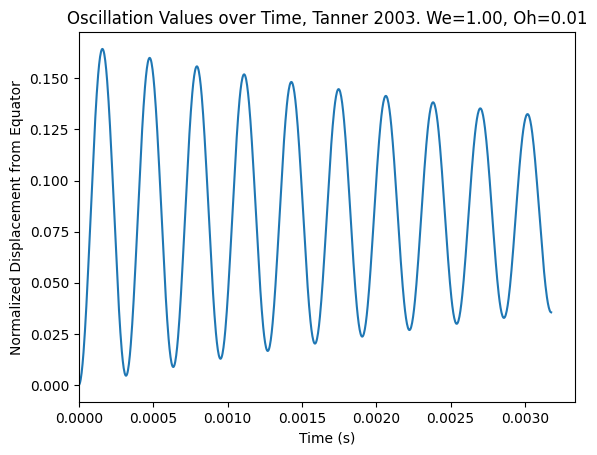

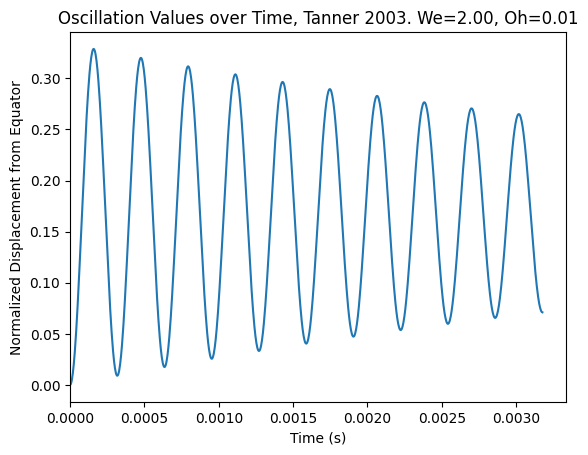

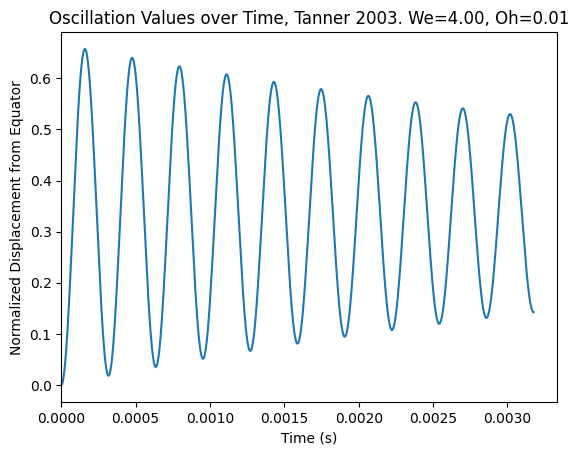

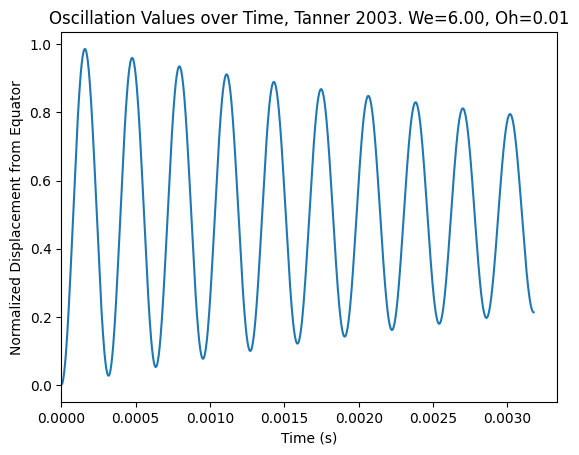

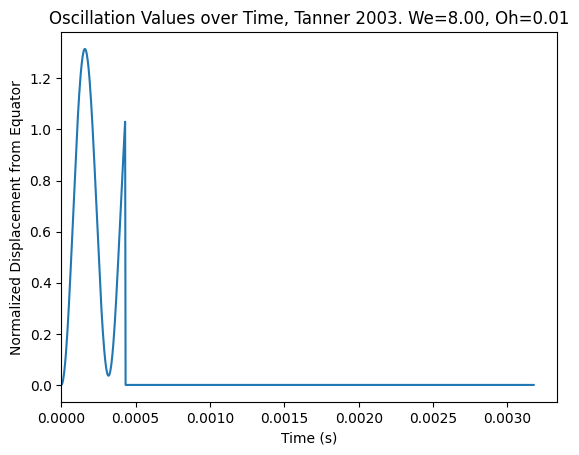

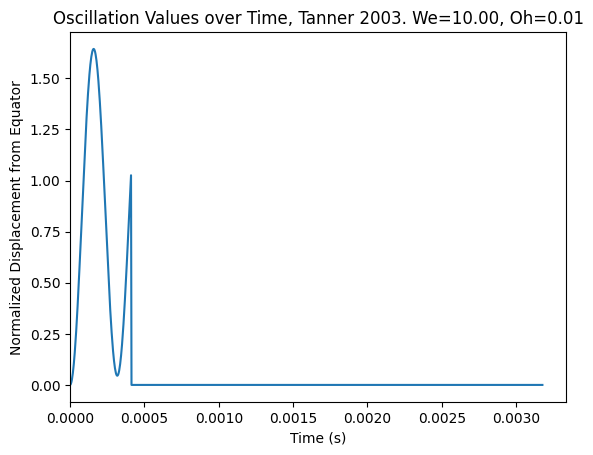

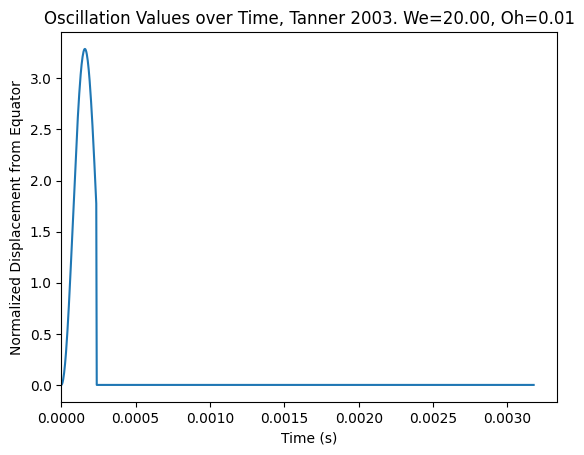

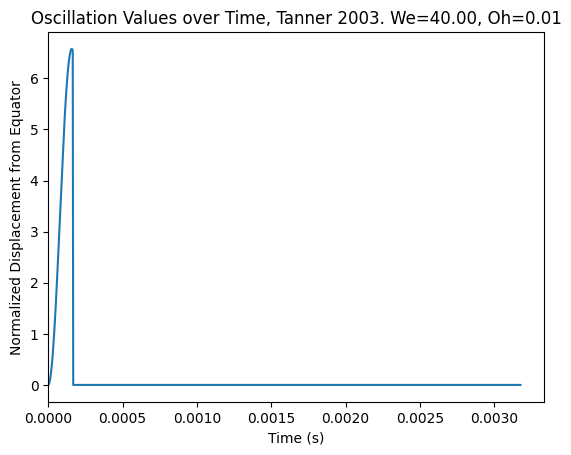

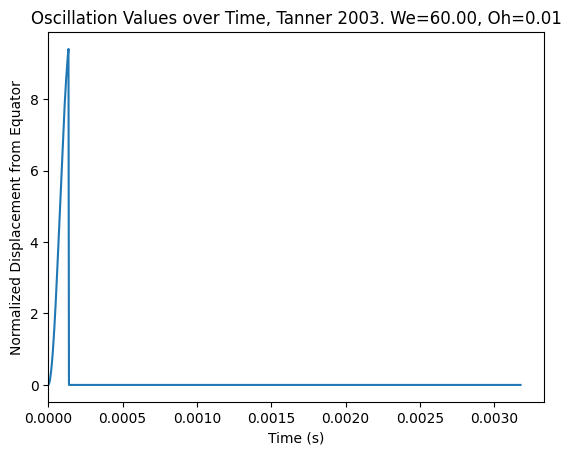

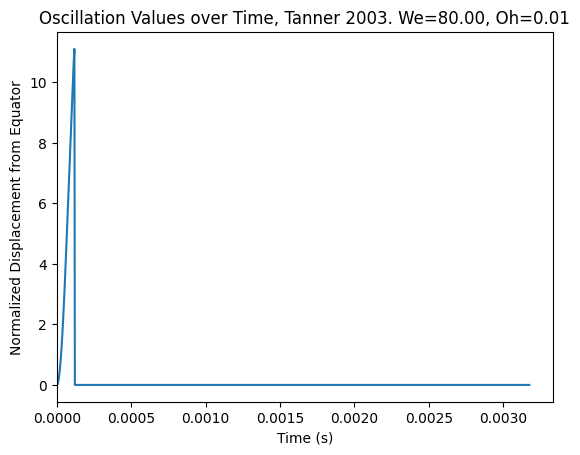

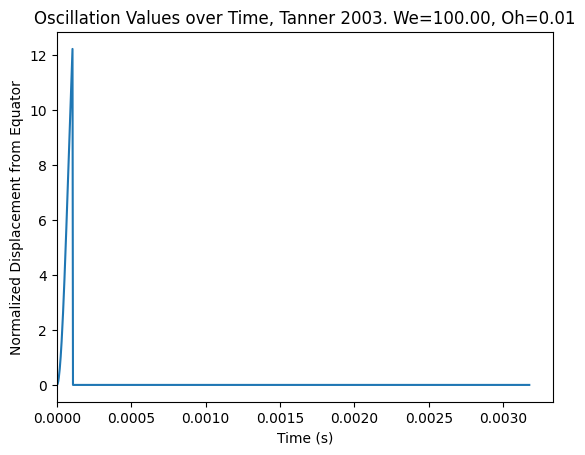

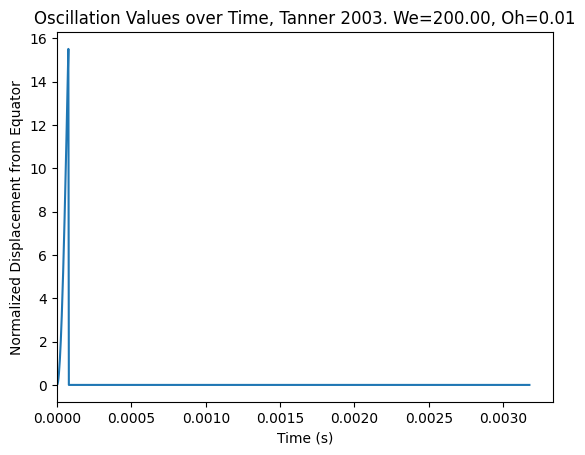

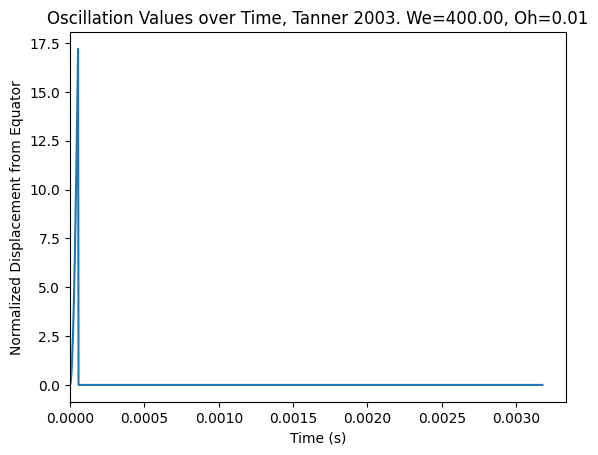

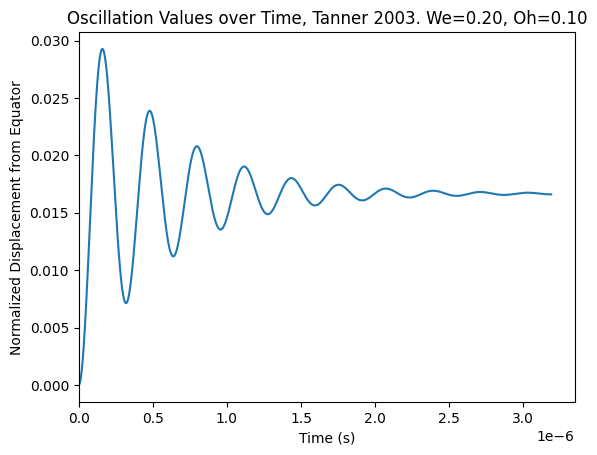

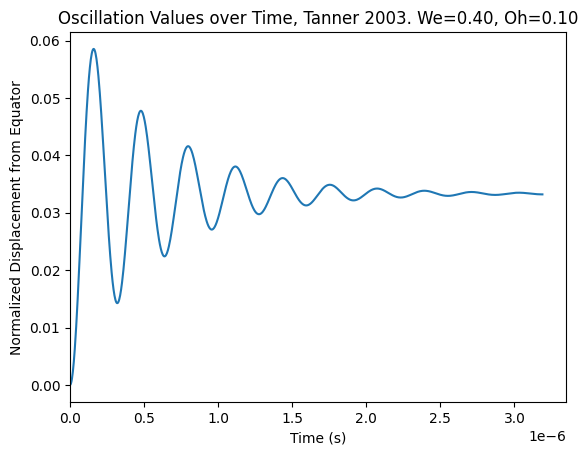

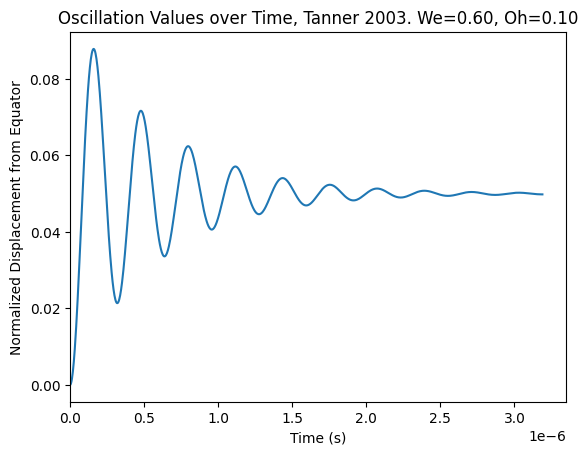

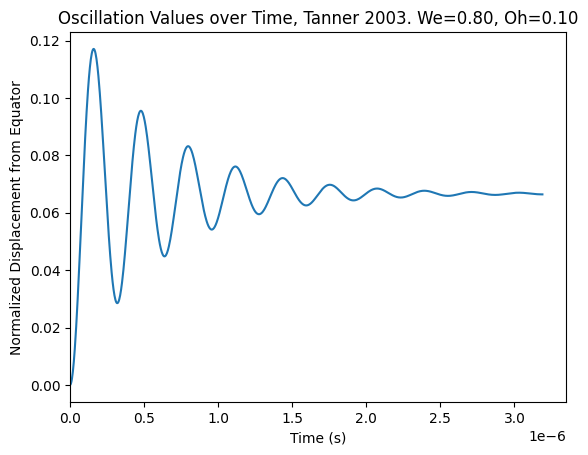

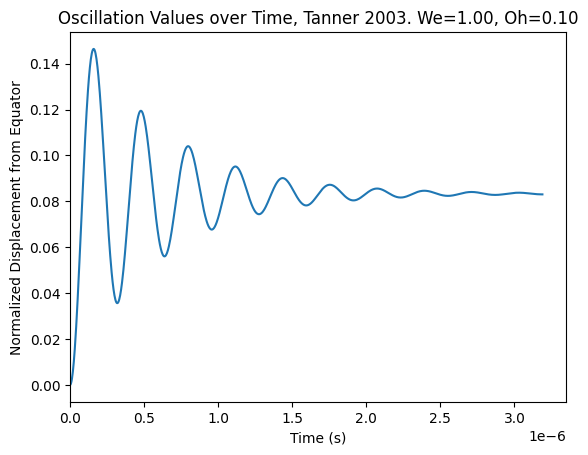

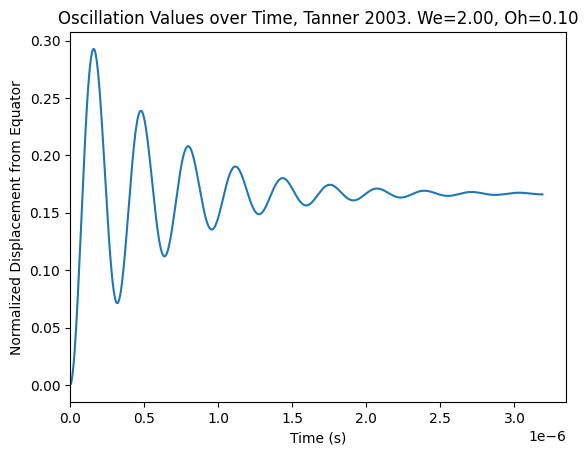

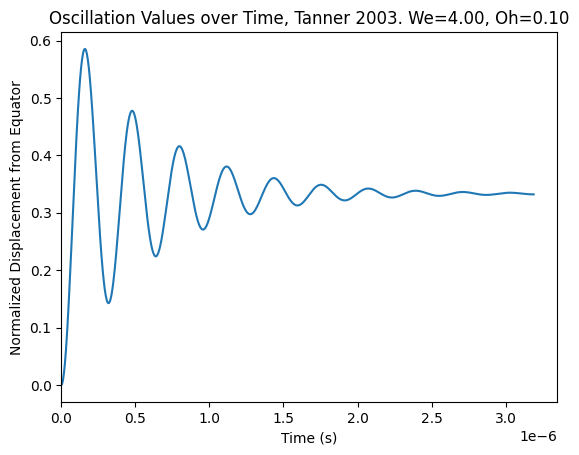

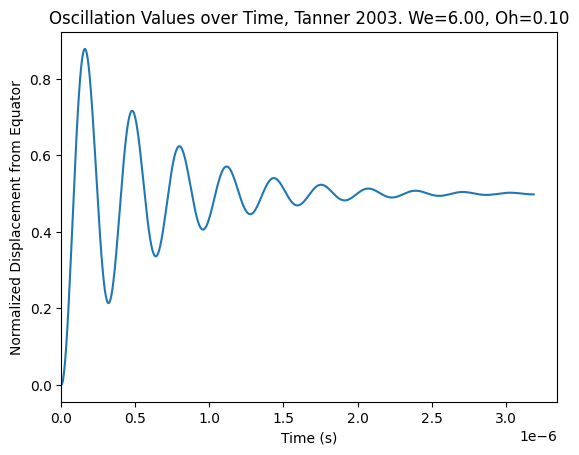

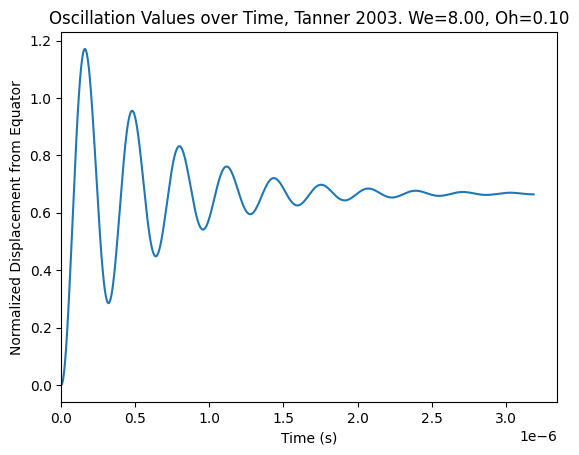

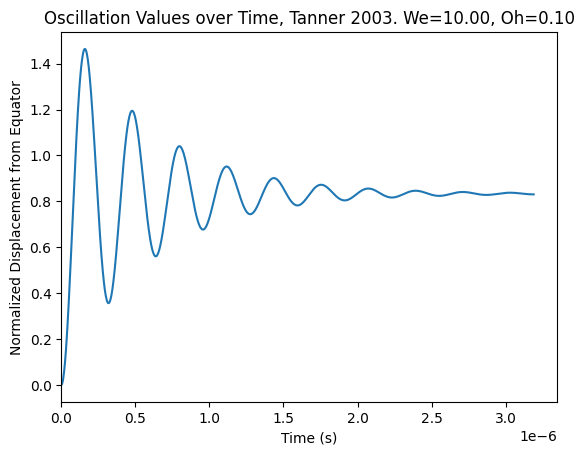

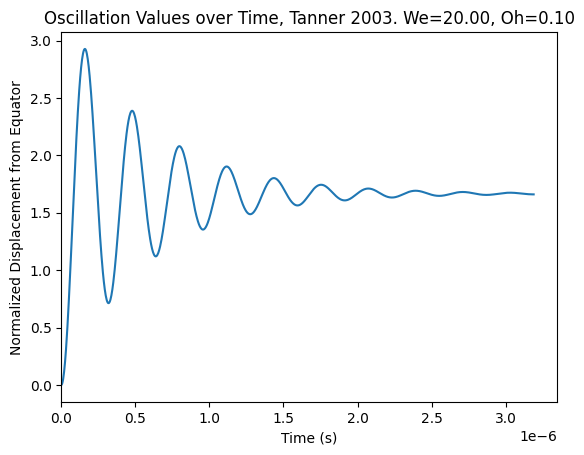

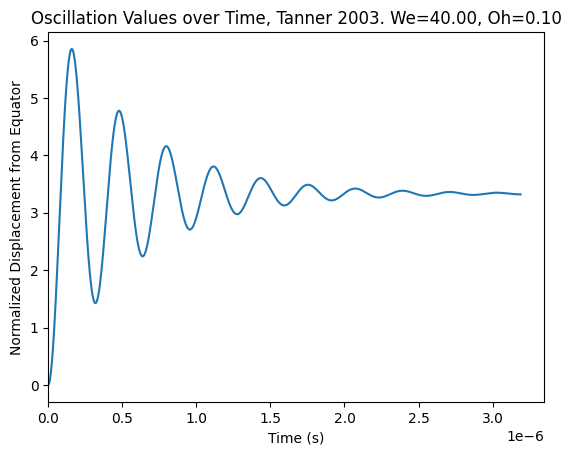

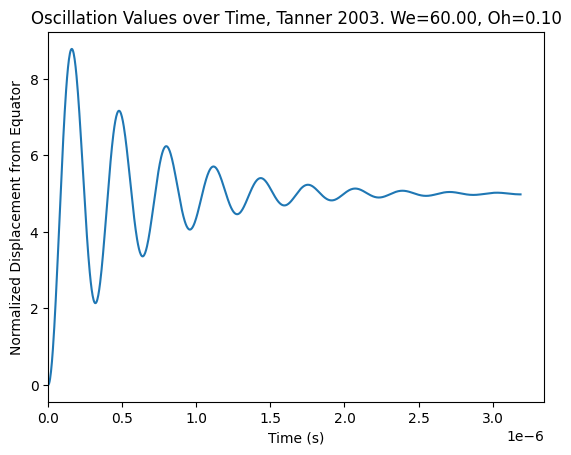

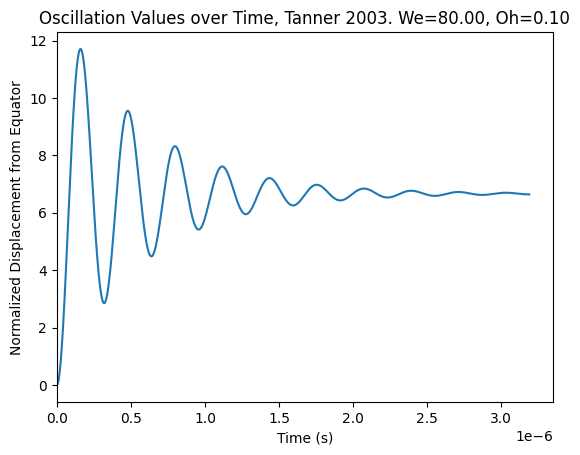

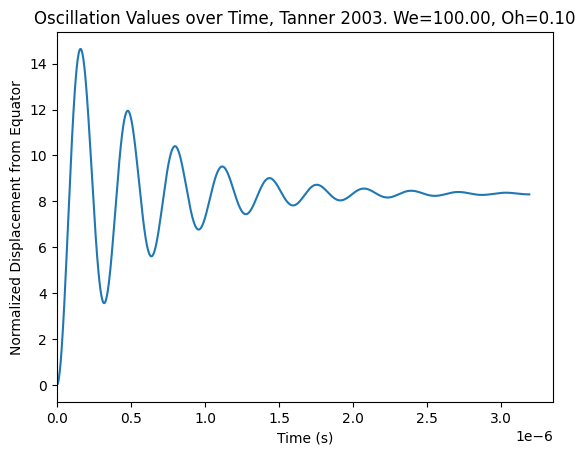

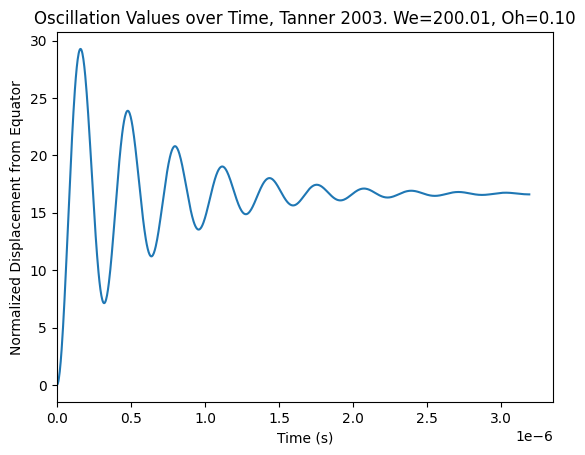

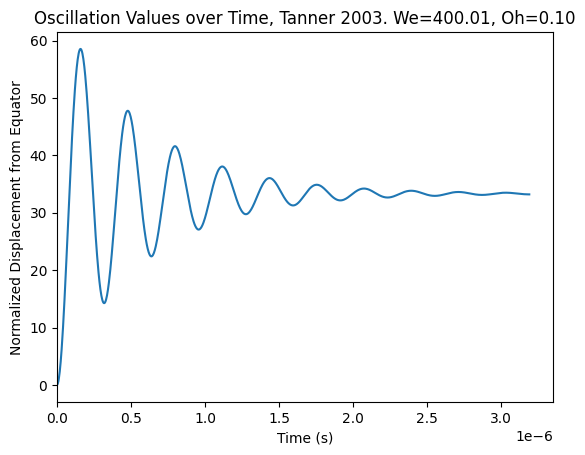

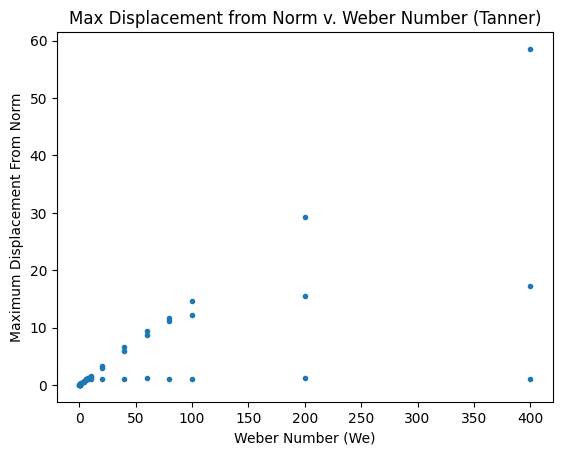

['5' '1' '1' '2' '2' 'o' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 's' 's' 's' 'c' '5'
 '1' '1' '2' '2' 'o' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 's' 's' 'c' '5' '1'
 '1' '2' '2' 'o' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 's' 's' 's' 'c']


In [ ]:
max_y_val_tanner = np.zeros(len(radius_values))  # array for max normalized displacement from sphere
We_tanner = np.zeros(len(radius_values))  # array for all the Weber numbers
regimes_Tan = np.empty(len(radius_values), dtype=str)
ratios = np.zeros(len(radius_values), dtype=float)
zeta = np.zeros(len(radius_values), dtype=float)

for k in range(len(radius_values)):

    #These values may be changed:
    rho_g = 1.18  #kg/m^3, density of gaseous ethylene
    rho_l = 997  #kg/m^3, density of liquid
    parent_r = radius_values[k]  #m, radius of droplet (~.2mm) **
    parent_vol = (4/3)*np.pi*(parent_r**3)
    sigma = 0.0708  #kg/s^2, surface tension
    u = velocity_values[k]  #m/s, velocity
    mu_l = 0.000894  #Pa*s, the dynamic viscocity of Jet A
    mu_g = 0.00185  #air viscosity, may change as a function of mach number (for Re)

    Oh = mu_l / np.sqrt( rho_l*parent_r*sigma )  #Ohnesorge number, from Faeth et al pg 636, between 10^-4 and 10^-2 for oscillatory behaviour
    We = rho_g*(u**2)*parent_r/sigma  #Weber number, eq 4
    We_tanner[k] = We

    Re = 2*rho_g*parent_r*u/mu_g

    volume = (4/3)*np.pi*parent_r**3  #a constant

    #Old implementation: assumes inital considitions are both 0. No time Marching.
    const1 = 5*mu_l/(rho_l*parent_r**2)
    const2 = 8*sigma/(rho_l*parent_r**3)
    const3 = 2*rho_g*u**2/(3*rho_l*parent_r**2)

    omega = np.sqrt( const2 - const1**2/4 )

    duration = 10*(2*np.pi/omega)  #seconds, the time we want to watch this particle
    len_t = 1000  #length of time vector

    dt = np.linspace(0,duration,len_t)  #s, time vector
    timestep = dt[1]-dt[0]  #timestep, in seconds

    y_vals = (const3/const2)*( 1 - np.exp(-const1*dt/2)*( np.cos(omega*dt) + (const1/(2*omega))*np.sin(omega*dt) ) )

    C_lambda = 5.5  #estimate from tanner paper
    d_0 = 0.15*1e-3  #0.15mm, from the table 2 tuning constant
    t_bu = C_lambda*d_0*np.sqrt(rho_l/rho_g)/u

    We_crit = 6
    We_bs = 80
    We_sc = 350

    for i in range(len_t):

        if (y_vals[i]>=1) and (const2-((const1**2)/4)>0) and (dt[i]>=t_bu):

            breakup_iteration = i

            Omega = np.sqrt( (8*sigma/(rho_l*(parent_r**3))) - (25*(mu_l**2)/(4*(rho_l**2)*(parent_r**4))) )

            K_br = 0
            k1 = 0.05  #tuned from CAB model in paper
            k2 = k1/np.sqrt(We_bs)  #calculated for continuity at We_bs
            k3 = k2/(We_sc**(1/4))  #calculated for continuity at We_sc

            #Define K_br from equation 3
            if We<=We_bs:
                K_br = k1*Omega  #Bag breakup
                regimes_Tan[k] = 'D'

            elif We<=We_sc:
                K_br = k2*Omega*np.sqrt(We)  #Stripping breakup
                regimes_Tan[k] = 'E'

            else:
                K_br = k3*Omega*(We**(3/4))  #Catastrophic breakup
                regimes_Tan[k] = 'F'

            min_radius = 1e-8  #10 nanometers as a safety floor
            product_r = parent_r*np.exp(-K_br*dt[i])  #Product drop radius, eq 4
            product_r = max(product_r,min_radius)

            product_vol = (4/3)*np.pi*(product_r**3)
            num_drops = int(np.round(parent_vol/product_vol))

            if num_drops>1e6:
                num_drops = 1e6  #cap at 1 mil drops per parent

            C_D = 0.44  #Schiller-Naumann correlation for CD of spherical bodies

            if Re<1:
                C_D = 24/Re

            elif Re<1000:
                C_D = 24/Re*(1 + 0.15*Re**0.687)

            r_32 = (parent_r**3)/(product_r**2)
            term = (5*C_D/4) + ( (18*(1-(parent_r/r_32)))/We )

            if term<0:
                term = -term

            A = np.sqrt(term)  #equation 8
            spray_angle = np.arctan(A)  #Spray angle measured from drop velocity vector
            vel_new = u*A  #Eq 5, new droplet normal velocities

            den = parent_r - y_vals[i]*parent_r/2
            den = max(den,1e-12)  #gaurd or else den --> 0 as y(i) --> 2 and b will --> infinity
            b = np.sqrt(parent_r**3/den)  #radius of the zy plane circle

            new_ypos = np.zeros(num_drops)
            new_zpos = np.zeros(num_drops)
            new_xvel = np.zeros(num_drops)
            new_yvel = np.zeros(num_drops)
            new_zvel = np.zeros(num_drops)

            for j in range(num_drops):

                drop_angle = 2*np.pi*j/num_drops

                new_ypos[j] = b*np.sin(drop_angle)  #initial y pos
                new_zpos[j] = b*np.cos(drop_angle)  #inital z pos

                new_xvel[j] = vel_new*np.cos(spray_angle)  #x velocity, a constant
                new_yvel[j] = vel_new*np.sin(spray_angle)*np.sin(drop_angle)  #y velocity
                new_zvel[j] = vel_new*np.sin(spray_angle)*np.cos(drop_angle)  #z velocity

            y_vals[i+1:] = 0
            break

    peak_indices,_ = find_peaks(y_vals)
    peak_values = y_vals[peak_indices]

    if np.max(y_vals)<=0.05:
        regimes_Tan[k] = '5'
    elif np.max(y_vals)<=0.1:
        regimes_Tan[k] = '10'
    elif np.max(y_vals)<=0.2:
        regimes_Tan[k] = '20'
    elif np.max(y_vals)<=1:
        regimes_Tan[k] = 'osc'
    else:

        if We<=We_bs:
            regimes_Tan[k] = 'bag'

        elif We<=We_sc:
            regimes_Tan[k] = 'str'

        else:
            regimes_Tan[k] = 'cat'

    #Plotting the y values
    plt.figure()
    plt.plot(dt,y_vals)
    plt.title(f'Oscillation Values over Time, Tanner 2003. We={We:.2f}, Oh={Oh:.2f}')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Displacement from Equator')  #y = 2x/a

    max_y_val_tanner[k] = np.max(y_vals)

    plt.xlim(left=0)
    plt.show()

plt.figure()
plt.plot(We_tanner,max_y_val_tanner,'.')
plt.title('Max Displacement from Norm v. Weber Number (Tanner)')
plt.xlabel('Weber Number (We)')
plt.ylabel('Maximum Displacement From Norm')
plt.show()

print(regimes_Tan)